# PROC OPTMODEL(ネットワークTSP)によるラストマイル配送ルートの最適化


## エグゼクティブサマリー

地域の物流会社は、1台の配送車両を一連の顧客停留所に順番に巡回させ、総移動距離を最小にしてデポへ戻らせる必要がある——これは日々のルートおよびシフト計画の根底にある巡回セールスマン問題(TSP)の構造である。本ノートブックは停留所の座標を生成し、対称なユークリッド距離行列を構築し、**PROC OPTMODEL**の`SOLVE WITH NETWORK /
TSP`ネットワークソルバーを用いて、全停留所のグラフ上で配送ツアーを構築する。その後、ソルバーが返したツアー順序をDATAステップに読み込み、デポを起点・終点とする閉じたルートを再構築し、距離行列から**実際の**総距離を測定する。以下に示すすべての数値は、実行された出力から計算されたものである。


## データソース

すべてのデータは`call streaminit(...)`と`rand(...)`によりインラインで生成される——外部ファイルやネットワークアクセスは一切ない。

| データセット | 行数 | 主要変数 | 説明 |
|---------|------|---------------|-------------|
| `stops` | 12(デポ1 + 顧客11) | `stop_id`, `name`, `x`, `y` | デポと顧客配送先の合成2次元座標(サービスエリアグリッド上のkm) |
| `tour` | 12 | `visit_order`, `node` | OPTMODELネットワークTSPソルバーが巡回する停留所の順序リスト。`OUT=(TOUR=...)`で書き出される |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | 座標から計算された区間距離・累計距離を伴う、デポを起点とする閉じたツアー |


ラストマイル配送業者は毎朝1台のバンを配車し、決まった顧客停留所群に配送してデポへ戻らせる。配車担当者は、すべての停留所をちょうど1回ずつ訪問する短い閉じたツアーを求めている——これが日々のルートおよびシフトスケジューリングの中核をなす巡回セールスマン問題(TSP)である。

SAS/ORは**`PROC OPTMODEL`**を通じてTSPソルバーを提供する:ノードと重み付きエッジ集合を宣言し、`SOLVE WITH NETWORK / TSP`を実行する。本ノートブックでは:

1. 停留所の座標と対称な距離行列を生成する。
2. 全停留所のグラフに対してOPTMODELネットワークTSPソルバーを呼び出す。
3. ソルバーのツアーを読み込み、デポを起点とする閉じたルートを再構築する。
4. ルートとその測定された総距離を、区間ごとに報告する。


## ステップ1 — 配送ネットワークの生成

100km x 100kmのサービスエリアの中心にデポを配置し、11の顧客停留所をグリッド上に一様分布させる。座標は固定された`streaminit`シードのもとで`rand('UNIFORM')`により生成されるため、ネットワークは再現可能である。デポは`stop_id = 1`であり、ルートはそこから出発しそこへ戻る。


In [1]:
データ stops;
    呼出 streaminit(20260531);
    長さ name $20;
    n_stops = 12;                 /* 1 depot + 11 customers */
    繰返 stop_id = 1 から n_stops;
        もし stop_id = 1 なら 繰返;
            name = 'デポ';
            x = 50; y = 50;       /* depot anchored at grid center */
        終了;
        他 繰返;
            name = cats('停留所_', PUT(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        終了;
        出力;
    終了;
    削除 n_stops;
実行;

処理 印刷 データ=stops noobs 見出;
    見出 stop_id = '停留所番号' name = '場所' x = 'X (km)' y = 'Y (km)';
    表題 '配送ネットワーク:デポと顧客停留所';
実行;


                                                   配送ネットワーク:デポと顧客停留所                                                    

          場所            停留所番号  X (km)  Y (km)
デポ                          1      50      50
停留所_01                      2    84.2    89.7
停留所_02                      3    93.1    73.6
停留所_03                      4    21.2      29
停留所_04                      5    49.4    73.4
停留所_05                      6    97.8    37.2
停留所_06                      7      28    51.3
停留所_07                      8    91.1    86.5
停留所_08                      9    89.2    65.6
停留所_09                     10      66    49.4
停留所_10                     11    52.2    27.4
停留所_11                     12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## ステップ2 — PROC OPTMODELによるTSPの求解

座標をOPTMODELに読み込み、完全無向エッジ集合`EDGES`(停留所のすべての非順序対)を宣言し、各エッジの重みを両端点間のユークリッド距離として定義する。`SOLVE WITH NETWORK / TSP`はそのグラフ上でツアーを構築し、`OUT=(TOUR=...)`により訪問順序をCSVへ書き出す。その順序を直ちに`tour`データセットへ読み戻す。


In [2]:
処理 optmodel;
    設定 CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Pull the stop coordinates in from the DATA step */
    READ データ stops INTO [stop_id] XC=x YC=y;

    /* Complete graph: one undirected edge per unordered pair of stops */
    設定 EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* Edge weight = straight-line (Euclidean) distance, in km */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Network TSP solver: visit every node and return to the start */
    solve WITH network /
        links = (include=EDGES 重み=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Read the solver's visiting order back in */
データ tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    入力 visit_order node;
実行;

処理 印刷 データ=tour noobs 見出;
    見出 visit_order = '訪問順' node = '停留所番号';
    表題 'OPTMODELネットワークTSPソルバーが返したツアー順序';
実行;


                                                   配送ネットワーク:デポと顧客停留所                                                    


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                                             OPTMODELネットワークTSPソルバーが返したツアー順序                                             

      訪問順            停留所番号
        1                1
        2                7
        3                4
        4               11
        5               12
        6               10
        7              


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## ステップ3 — 閉じたルートの再構築と距離の測定

ソルバーが返すのは停留所を訪問する*順序*のみである。これをドライバー向けマニフェストに変換するため、各停留所の名前と座標を`SET ... POINT=`ルックアップで取得し、各区間の距離を積算し、最後の区間をデポへ戻すことでループを閉じる。`leg_km`は各停留所に*到着する*区間の長さであり、`cum_km`はデポからの累計距離である。


In [3]:
データ route;
    設定 tour 終了=last;
    /* Look up this stop's coordinates and name by its id */
    ptr = node;
    設定 stops point=ptr;

    長さ step_name $20;
    step_name = name;

    保存 prevx prevy firstx firsty cum_km;
    もし _n_ = 1 なら 繰返;
        firstx = x; firsty = y;      /* remember the depot */
        leg_km = 0;                  /* no leg arrives at the start */
        cum_km = 0;
    終了;
    他 繰返;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    終了;
    prevx = x; prevy = y;
    出力;

    もし last なら 繰返;
        /* Closing leg: last stop back to the depot */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'デポ';
        x = firstx; y = firsty;
        出力;
        呼出 symputx('total_km', PUT(cum_km, 8.2));
    終了;
    保持 visit_order node step_name x y leg_km cum_km;
実行;

処理 印刷 データ=route noobs 見出;
    見出 visit_order = 'ステップ' node = '停留所番号' step_name = '場所'
          x = 'X (km)' y = 'Y (km)'
          leg_km = '区間距離(km)' cum_km = '累計距離(km)';
    書式 leg_km cum_km 7.2;
    表題 "閉じた配送ルート(合計:&total_km km)";
実行;


                                                 閉じた配送ルート(合計:258.14 km)                                                 

        ステップ            停留所番号            場所  X (km)  Y (km)          区間距離(km)          累計距離(km)
           1                1  デポ                50      50              0.00              0.00
           2                7  停留所_06            28    51.3             22.04             22.04
           3                4  停留所_03          21.2      29             23.31             45.35
           4               11  停留所_10          52.2    27.4             31.04             76.39
           5               12  停留所_11          62.4    38.2             14.86             91.25
           6               10  停留所_09            66    49.4             11.76            103.01
           7                6  停留所_05          97.8    37.2             34.06            137.07
           8                9  停留所_08          89.2    65.6             29.67            166.75
           9  


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## ステップ4 — 読みやすいドライバーマニフェスト

最後に、ルートを1つの人間が読みやすい文字列——デポから顧客を巡り再びデポへ戻る停留所名の並び——と、バンが走行する測定された総距離にまとめる。


In [4]:
データ manifest;
    設定 route 終了=last;
    長さ route_text $250;
    保存 route_text '';
    もし _n_ = 1 なら route_text = strip(step_name);
    他 route_text = catx(' -> ', route_text, strip(step_name));
    もし last なら 繰返;
        total_km = cum_km;
        保持 route_text total_km;
        出力;
    終了;
実行;

処理 印刷 データ=manifest noobs 見出;
    見出 route_text = '最適化された配送ルート'
          total_km   = '合計距離(km)';
    書式 total_km 7.2;
    表題 '配送マニフェスト';
実行;


                                                        配送マニフェスト                                                        

                                                                                                                                                                                     最適化された配送ルート          合計距離(km)
デポ -> 停留所_06 -> 停留所_03 -> 停留所_10 -> 停留所_11 -> 停留所_09 -> 停留所_05 -> 停留所_08 -> 停留所_02 -> 停留所_07 -> 停留所_01 -> 停留所_04 -> デポ                                                                                      258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## ステップ5 — ルートのプロット

図を見ればツアーが妥当であることが確認できる:停留所が訪問順に接続され、デポが示され、明らかに無駄な交差もない。閉じたツアーを、サービスエリアグリッド上の連続した線分として描画する。


                                                        配送マニフェスト                                                        




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


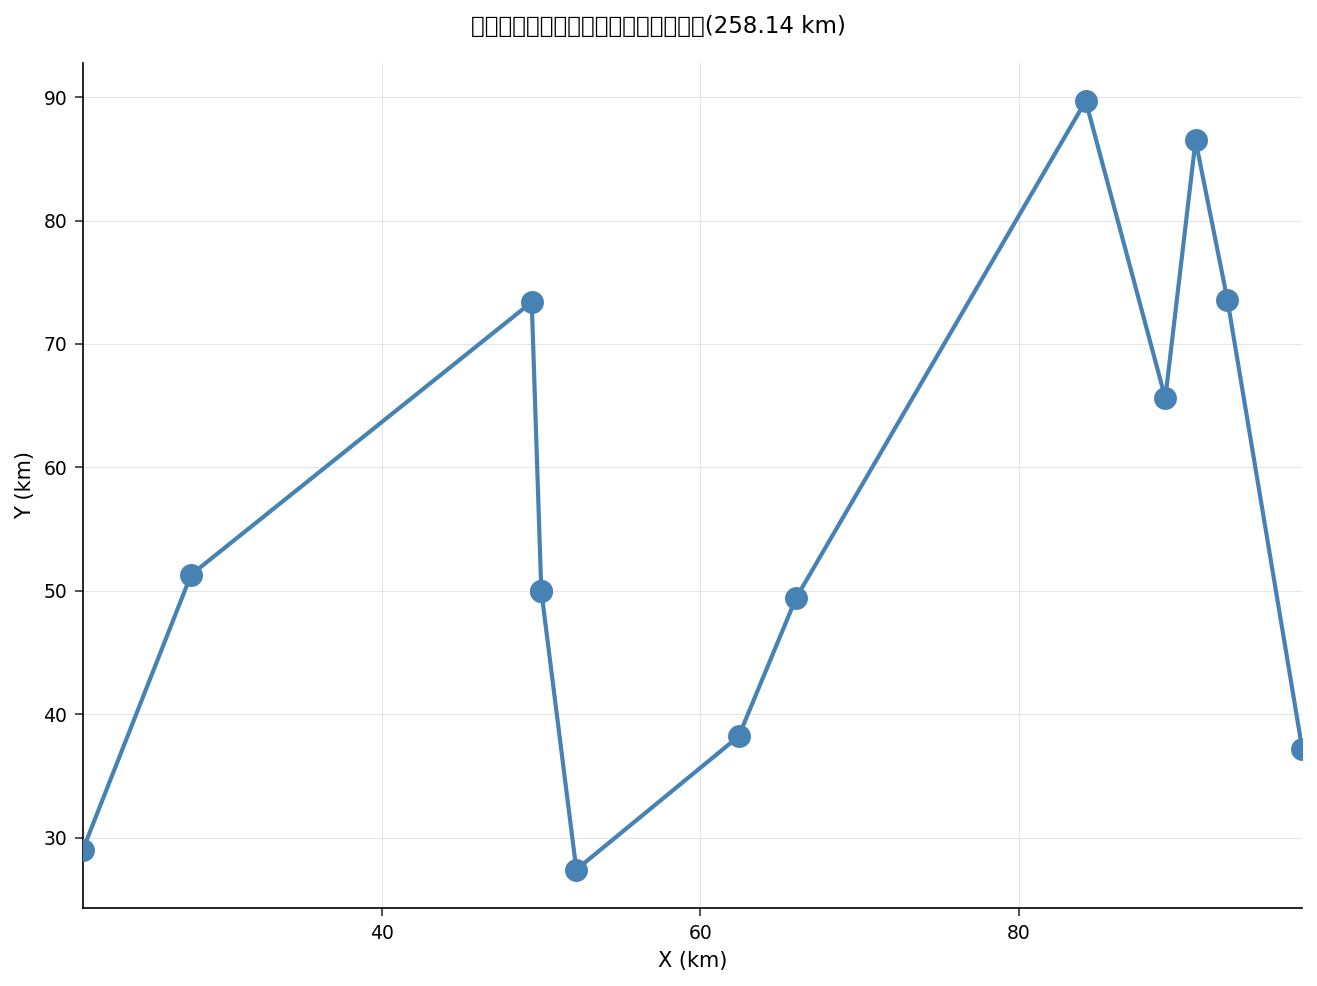

In [5]:
処理 SGPLOT データ=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS 見出='X (km)' grid;
    YAXIS 見出='Y (km)' grid;
    表題 "最適化されたラストマイル配送ツアー(&total_km km)";
実行;


## 結果の解釈

- **ルート。** `route`テーブルと`manifest`テーブルは、OPTMODELネットワークTSPソルバーが12停留所の完全グラフ上で生成した、デポから始まりデポで終わる閉じたツアーを示す。`Total Distance`(総距離)は*測定値*である:各区間のユークリッド距離(`leg_km`)の合計であり、想定値ではなくネットワークの実際の幾何構造を反映している。
- **ここでネットワークソルバーを用いる理由。** 顧客停留所が11あると、`11! / 2 = 19,958,400`通りの異なる閉じたツアーが存在するため、配車担当者には列挙ではなくアルゴリズムが必要である。`SOLVE WITH NETWORK / TSP`は、分析者が手作業で探索を書くことなく、重み付きエッジ集合から直接ツアーを構築する。
- **順序からマニフェストへ。** ソルバーが返すのは訪問*順序*であり、DATAステップはそれを運用可能な成果物——名前付きの停留所、区間ごとの距離、走行距離の積算、ドライバーが従える1行のマニフェスト——へと変換する。
- **運用上の拡張。** 同じOPTMODELの枠組みは、より豊かなルーティングにも拡張できる:追加のネットワークオプションとして容量制約や時間枠制約を加える、直線距離の代わりに走行時間でエッジを重み付けする、あるいは複数車両にわたって停留所を分割してから車両ごとにTSPを解く、などである。
